## A historical look at S&P 500 

In [1]:
import pandas as pd

## Read SP500 CSV

In [2]:
spx = pd.read_csv("../../../data/SP500.csv")
spx['Date'] = pd.to_datetime(spx['Date'], format="%Y%m%d")
spx['Date'] = spx['Date'].dt.date
spx['Year'] = spx['Date'].map(lambda x : x.year)
#Read a subset of the data
# conn = sqlite3.connect('../../Data/SP500.db')
# spx = pd.read_sql("SELECT * FROM SP500 WHERE Date BETWEEN 20200101 AND 20240101", conn)
# conn.close()

In [6]:
historical = []
for year in spx.Year.unique():
    if year not in [1927,  2025]: #These two years are not complete
        temp = spx[spx.Year == year]['Close']
        temp.name = year
        temp = temp.reset_index(drop=True)
        temp = temp/temp[0] - 1 #Percent re
        historical.append(temp)

In [19]:
hist = pd.concat(historical, axis=1)

In [32]:
hist.loc[245:249]

,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
245,0.325451,-0.160016,-0.293673,-0.476972,-0.130952,NaN,-0.103858,0.376446,0.242537,-0.368576,...,-0.009343,0.125466,0.189004,-0.103564,0.283339,0.134153,0.269111,-0.203104,0.243320,0.250488
246,0.319820,-0.160822,-0.284230,-0.498423,-0.125661,NaN,-0.102868,0.379600,0.258209,-0.391022,...,0.002959,0.123369,0.188460,-0.127869,0.284451,0.131820,0.277002,-0.198428,0.248581,0.259600
247,0.331081,-0.158001,-0.298867,-0.497792,-0.126984,NaN,-0.069238,0.378549,0.270896,-0.384525,...,0.001356,0.124775,0.187202,-0.084617,0.284200,0.132649,0.294674,-0.201674,0.250367,0.273510
248,0.350225,-0.135429,-0.305005,-0.510410,-0.107143,NaN,-0.060336,0.398528,0.273134,-0.376255,...,-0.000826,0.127304,0.188141,-0.076778,0.290785,0.136670,0.293377,-0.211270,0.250830,0.272993
249,0.371059,NaN,-0.288952,-0.497792,-0.084656,NaN,NaN,0.412198,0.264179,-0.376846,...,0.009795,0.117884,0.190320,-0.077925,0.290829,0.146584,0.295187,-0.197498,0.247295,0.258919


<Axes: title={'center': 'SP500 Move in the last 100 Years'}>

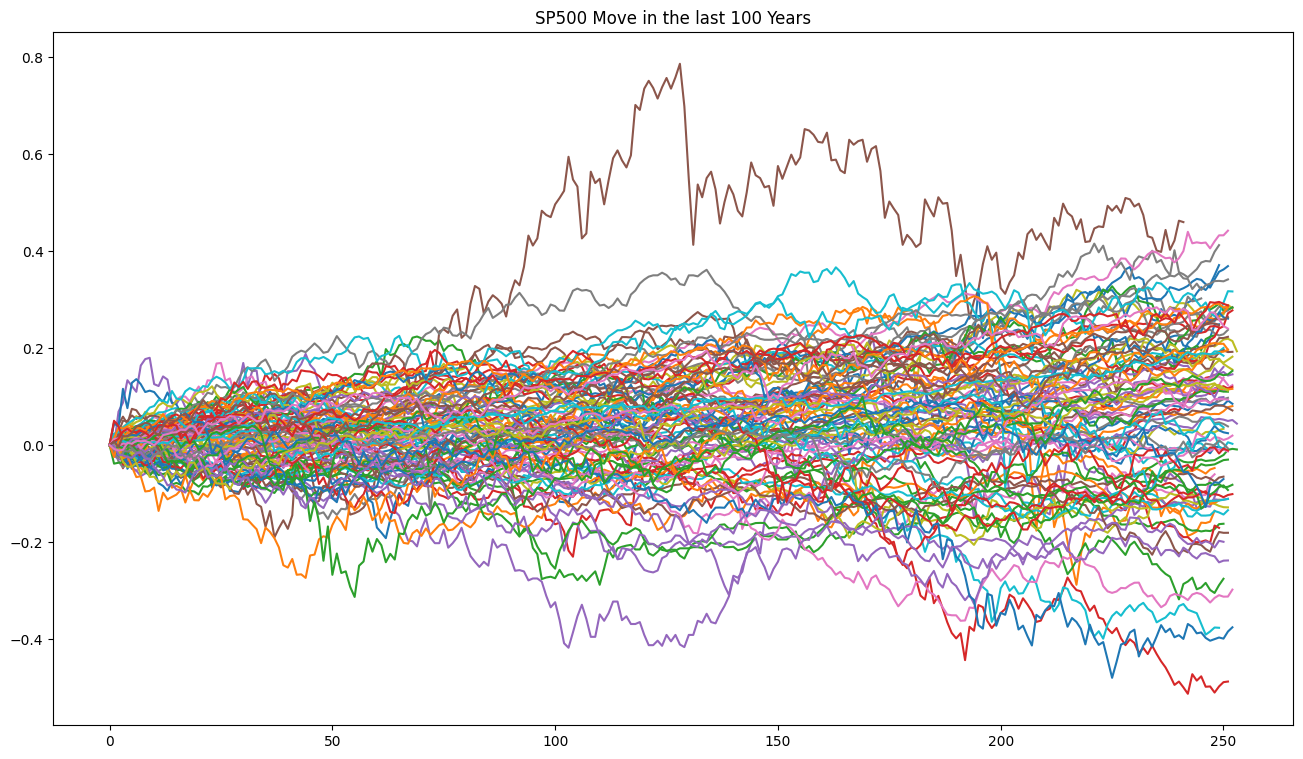

In [10]:
hist.plot(figsize=(16,9), legend=False, title="Yearly move on the SP500 Move in the last 100 Years")

## Historical simulation is great. What if we want to see a 1000 or even 10000 simulated path? 